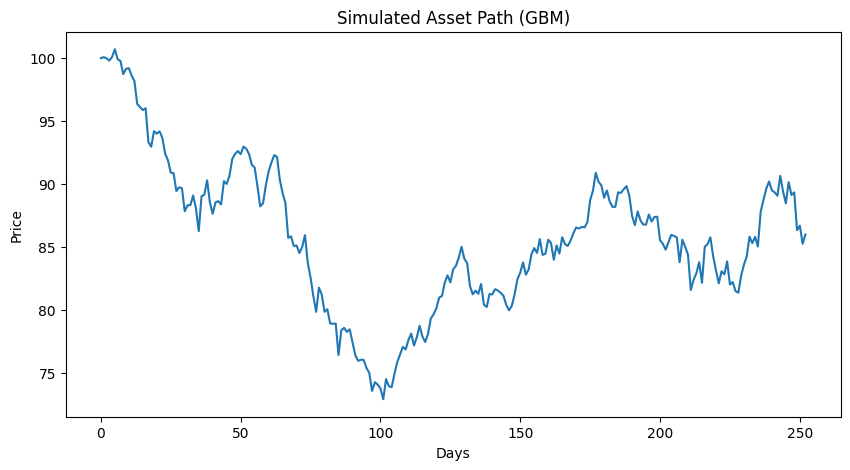

In [11]:
import sys
import os

# 1. Add the root directory to the path so we can import 'core'
sys.path.append(os.path.abspath(os.path.join('..')))

from core.stochastic import generate_gbm
import matplotlib.pyplot as plt

# 2. Run the simulation
path = generate_gbm(s0=100, mu=0.10, sigma=0.20, dt=1/252, steps=252)

# 3. Visualize
plt.figure(figsize=(10,5))
plt.plot(path)
plt.title("Simulated Asset Path (GBM)")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()

In [12]:
import numpy as np

# 1. Calculate Daily Log Returns from your simulated 'path'
# We use log returns because they are time-additive (Math BS requirement!)
log_returns = np.log(path / path.shift(1)).dropna()

# 2. Calculate the 5th Percentile (95% VaR)
# This is the "Historical Simulation" method applied to your synthetic data
var_95 = np.percentile(log_returns, 5)

# 3. Output the result
print(f"--- Risk Metrics ---")
print(f"95% 1-Day VaR (Log): {var_95:.4f}")
print(f"Worst 5% of days start at a loss of: {abs(var_95)*100:.2f}%")

--- Risk Metrics ---
95% 1-Day VaR (Log): -0.0200
Worst 5% of days start at a loss of: 2.00%
